<a href="https://colab.research.google.com/github/www-fidezDAE/fidez.RDS/blob/main/ARAMCO_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

In [ ]:
pip install pandas numpy matplotlib statsmodels tensorflow scikit-learn openpyxl

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving saudi_aramco_data.csv to saudi_aramco_data.csv


Objective 1: Preprocessing: Incorporation of technical indicators like moving averages, Bollinger bands and Relative Strength Index (RSI)

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('saudi_aramco_data.csv')  # Ensure 'stock_data.csv' has columns: 'Open', 'High', 'Low', 'Close', 'Volume'

# Moving Average (MA)
def moving_average(df, window=20):
    df[f'MA_{window}'] = df['Close'].rolling(window=window).mean()

# Bollinger Bands
def bollinger_bands(df, window=20, num_std_dev=2):
    df['MA20'] = df['Close'].rolling(window=window).mean()
    df['Bollinger_Upper'] = df['MA20'] + (df['Close'].rolling(window=window).std() * num_std_dev)
    df['Bollinger_Lower'] = df['MA20'] - (df['Close'].rolling(window=window).std() * num_std_dev)

# Relative Strength Index (RSI)
def rsi(df, window=14):
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

# Apply the functions to the DataFrame
moving_average(df, window=20)
bollinger_bands(df, window=20, num_std_dev=2)
rsi(df, window=14)

# Print necessary parameters
print("Moving Averages:")
print(df[['Close', 'MA_20']].tail())  # Adjust the column name as necessary

print("\nBollinger Bands:")
print(df[['Close', 'MA20', 'Bollinger_Upper', 'Bollinger_Lower']].tail())

print("\nRelative Strength Index (RSI):")
print(df[['Close', 'RSI']].tail())

# Save the modified DataFrame to a new CSV file
df.to_csv('stock_data_with_indicators.csv', index=False)

Moving Averages:
          Close    MA_20
1159  27.750000  27.8875
1160  27.950001  27.8800
1161  27.950001  27.8725
1162  28.200001  27.8700
1163  28.150000  27.8600

Bollinger Bands:
          Close     MA20  Bollinger_Upper  Bollinger_Lower
1159  27.750000  27.8875        28.814791        26.960209
1160  27.950001  27.8800        28.802469        26.957532
1161  27.950001  27.8725        28.789862        26.955138
1162  28.200001  27.8700        28.783294        26.956706
1163  28.150000  27.8600        28.755369        26.964632

Relative Strength Index (RSI):
          Close        RSI
1159  27.750000  37.704930
1160  27.950001  42.857169
1161  27.950001  47.368432
1162  28.200001  53.333342
1163  28.150000  52.459006


Objective 2: Exploratory Data Analysis (EDA): Analysis of trends, seasonality, and correlations

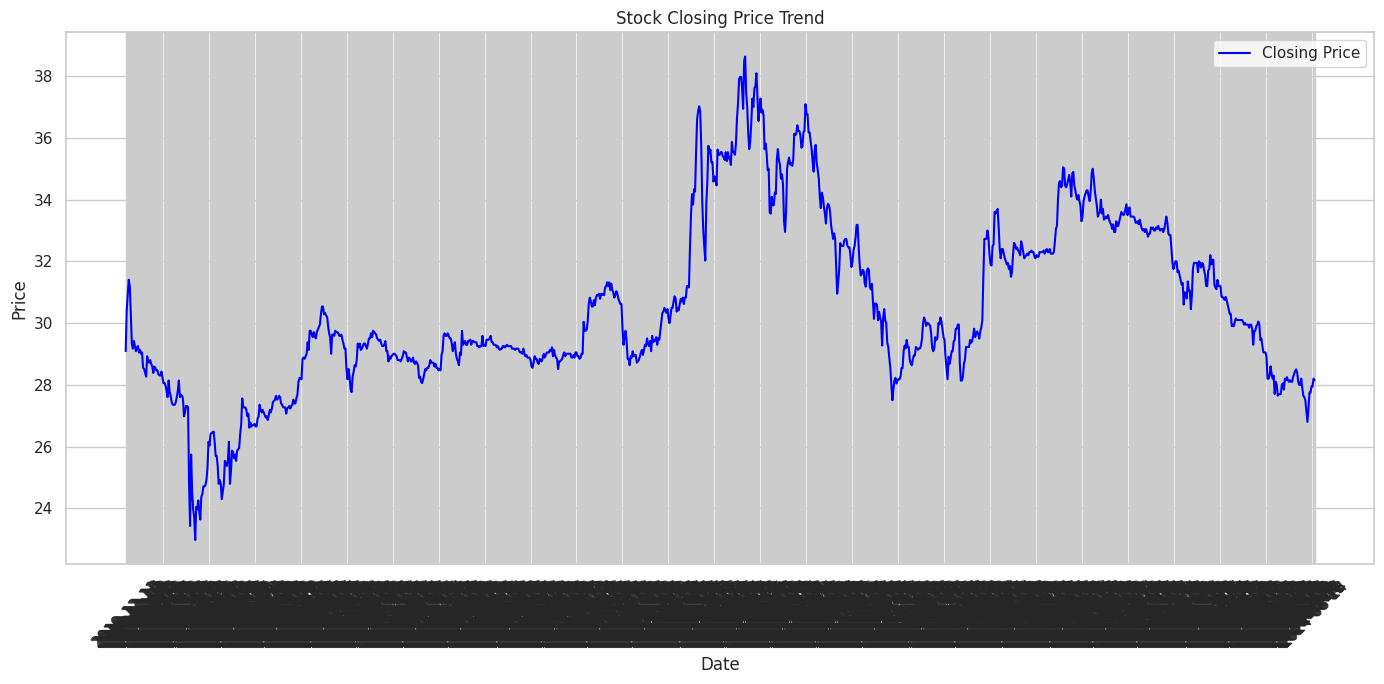

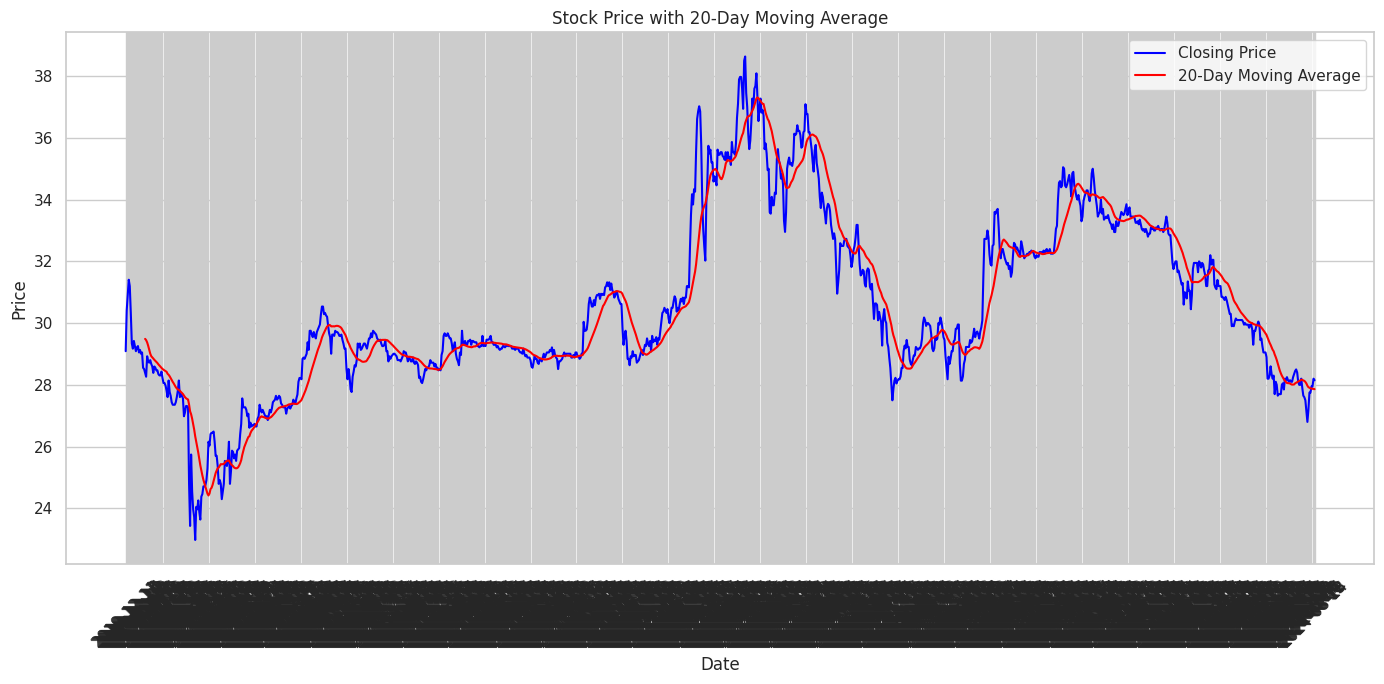

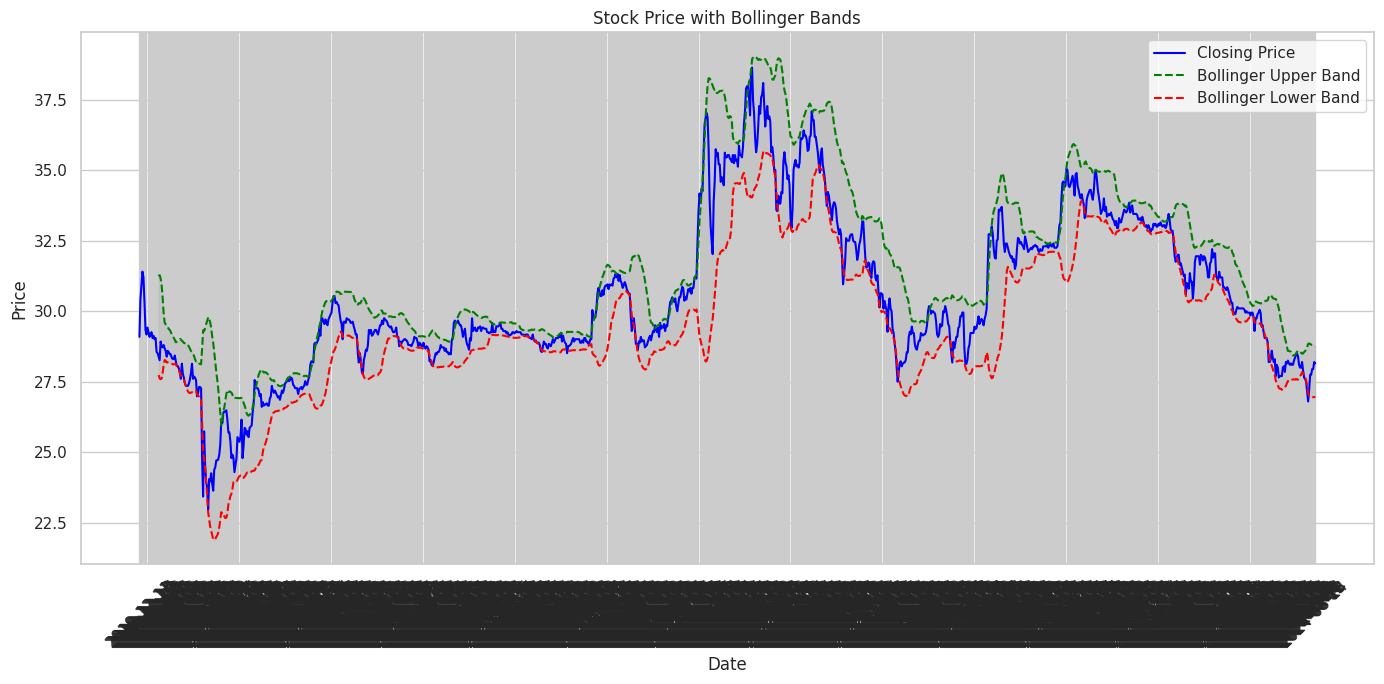

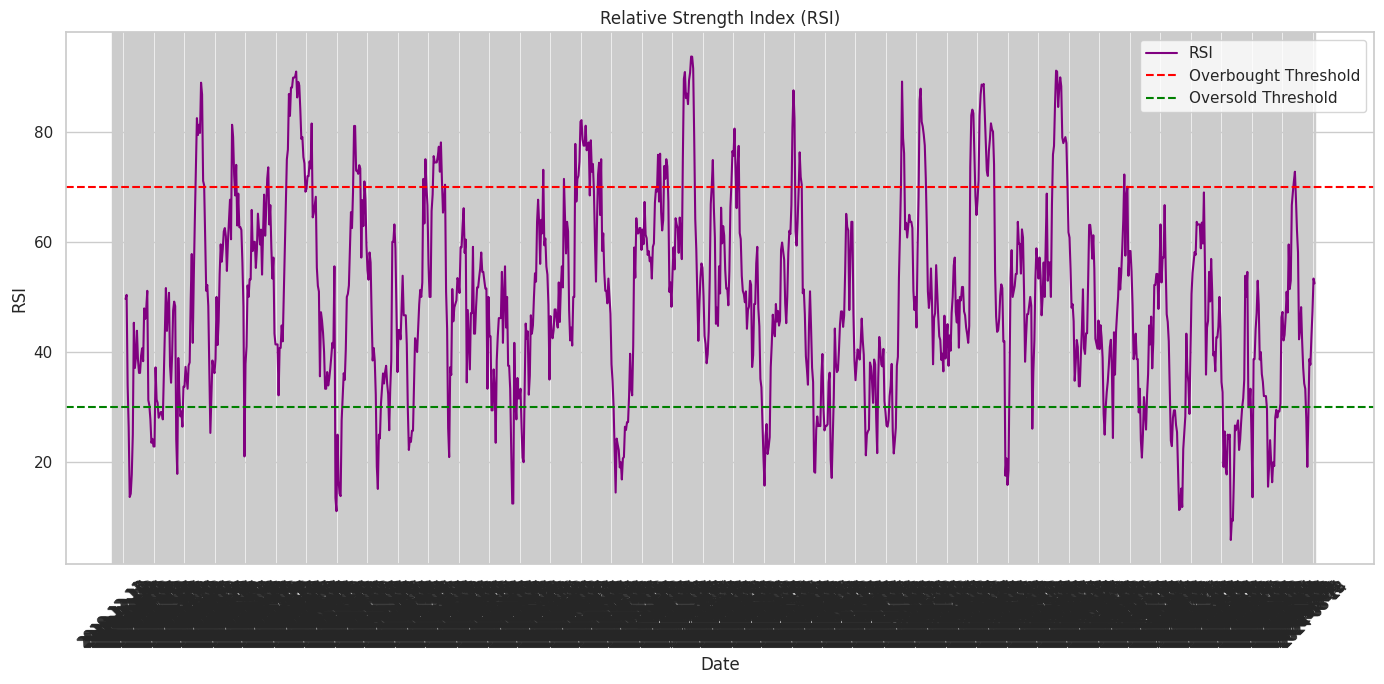

Correlation Matrix:
                    Close    Volume     MA_20  Bollinger_Upper  \
Close            1.000000  0.012227  0.956366         0.934313   
Volume           0.012227  1.000000  0.014543         0.034835   
MA_20            0.956366  0.014543  1.000000         0.969773   
Bollinger_Upper  0.934313  0.034835  0.969773         1.000000   
Bollinger_Lower  0.910936 -0.009628  0.960655         0.863846   
RSI              0.163553 -0.024119 -0.079326        -0.044642   

                 Bollinger_Lower       RSI  
Close                   0.910936  0.163553  
Volume                 -0.009628 -0.024119  
MA_20                   0.960655 -0.079326  
Bollinger_Upper         0.863846 -0.044642  
Bollinger_Lower         1.000000 -0.112956  
RSI                    -0.112956  1.000000  


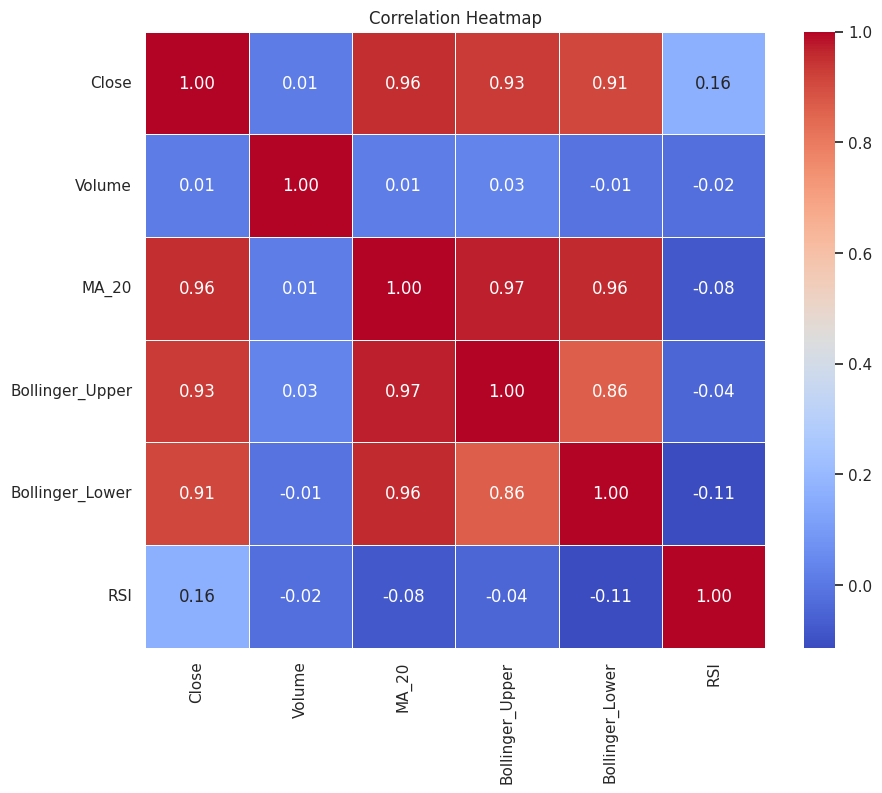

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('stock_data_with_indicators.csv')  # Ensure 'stock_data_with_indicators.csv' includes technical indicators

# Set plot style
sns.set(style="whitegrid")

# Plot closing price trend
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Close'], label='Closing Price', color='blue')
plt.title('Stock Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot moving average
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Close'], label='Closing Price', color='blue')
plt.plot(df['Date'], df['MA_20'], label='20-Day Moving Average', color='red')
plt.title('Stock Price with 20-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Bollinger Bands
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Close'], label='Closing Price', color='blue')
plt.plot(df['Date'], df['Bollinger_Upper'], label='Bollinger Upper Band', color='green', linestyle='--')
plt.plot(df['Date'], df['Bollinger_Lower'], label='Bollinger Lower Band', color='red', linestyle='--')
plt.fill_between(df['Date'], df['Bollinger_Lower'], df['Bollinger_Upper'], color='gray', alpha=0.1)
plt.title('Stock Price with Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Relative Strength Index (RSI)
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought Threshold')
plt.axhline(30, color='green', linestyle='--', label='Oversold Threshold')
plt.title('Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation analysis
correlation_matrix = df[['Close', 'Volume', 'MA_20', 'Bollinger_Upper', 'Bollinger_Lower', 'RSI']].corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Heatmap of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Objective 3: Model Training: Use of a variety of models (LSTM, Random Forest, XGBoost, ARIMA, linear multiple regression

Linear Regression Coefficients: [-5.06457931e-01  8.04347806e-01  6.82121601e-01 -5.88379900e-10
  6.36534812e-03 -1.92537128e-03  1.46560675e-02  2.21992688e-03]
Linear Regression Model:
  RMSE: 0.14
  MSE: 0.02
  MAE: 0.10
  MAPE: 0.32%
  R-squared: 1.00

Random Forest Feature Importances: [2.86498163e-03 5.56872922e-01 4.38539683e-01 4.07858684e-04
 2.61937735e-04 3.10702391e-04 3.38268326e-04 4.03645576e-04]
Random Forest Model:
  RMSE: 0.20
  MSE: 0.04
  MAE: 0.13
  MAPE: 0.43%
  R-squared: 1.00

XGBoost Model Parameters: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_oneho

<ipython-input-59-cfd929603f21>:99: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(df.select_dtypes(include=np.number).mean(), inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_23 (LSTM)                       │ (None, 50)                  │          11,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 35,555 (138.89 KB)

 Trainable params: 11,851 (46.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,704 (92.60 KB)

None
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
LSTM Model:
  RMSE: 525095.95
  MSE: 275725758409.28
  MAE: 313259.38
  MAPE: 1040657.49%
  R-squared: -33731944708.96



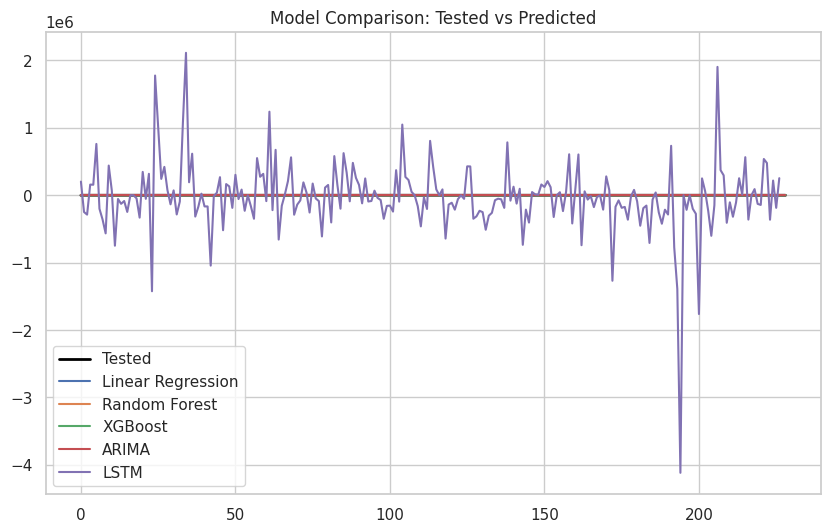

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Load dataset
df = pd.read_csv('stock_data_with_indicators.csv')  # Ensure your dataset contains all necessary indicators

# Prepare features and target
features = ['Open', 'High', 'Low', 'Volume', 'MA_20', 'Bollinger_Upper', 'Bollinger_Lower', 'RSI']
target = 'Close'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a function to evaluate and print model metrics
def evaluate_model(y_test, y_pred, model_name):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name} Model:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R-squared: {r2:.2f}")
    print()

# 1. Linear Multiple Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
print("Linear Regression Coefficients:", lin_reg.coef_)
y_pred_lin_reg = lin_reg.predict(X_test)
evaluate_model(y_test, y_pred_lin_reg, 'Linear Regression')

# 2. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Feature Importances:", rf_model.feature_importances_)
y_pred_rf = rf_model.predict(X_test)
evaluate_model(y_test, y_pred_rf, 'Random Forest')

# 3. XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=1000, random_state=42)
xgb_model.fit(X_train, y_train)
print("XGBoost Model Parameters:", xgb_model.get_params())
y_pred_xgb = xgb_model.predict(X_test)
evaluate_model(y_test, y_pred_xgb, 'XGBoost')

# 4. ARIMA (Using just the 'Close' series, handle this separately)
# Prepare ARIMA data
y_train_arima = y_train.values
y_test_arima = y_test.values

# Fit ARIMA model (Example with (5,1,0) order, tune as necessary)
arima_model = ARIMA(y_train_arima, order=(5,1,0))
arima_fit = arima_model.fit()
# Summary of the ARIMA model
print(arima_fit.summary())

# Make ARIMA predictions
arima_pred = arima_fit.forecast(steps=len(y_test_arima))
evaluate_model(y_test_arima, arima_pred, 'ARIMA')

# Check for NaNs in the test data and predicted data
print("NaNs in y_test_lstm:", np.isnan(y_test_lstm).sum())
print("NaNs in y_pred_lstm:", np.isnan(y_pred_lstm).sum())

# Drop rows with NaN values
y_test_lstm = y_test_lstm[~np.isnan(y_test_lstm)]
y_pred_lstm = y_pred_lstm[~np.isnan(y_pred_lstm)]

# Drop rows with NaN values
y_test_lstm = y_test_lstm[~np.isnan(y_test_lstm)]
y_pred_lstm = y_pred_lstm[~np.isnan(y_pred_lstm)]

# Remove rows with missing values from the entire dataset
df = df.dropna()

# After dropping NaNs, prepare the data as usual
X = df[features]
y = df[target].loc[X.index]

# Impute missing values with the mean (or use other techniques)
df.fillna(df.select_dtypes(include=np.number).mean(), inplace=True)


# 5. LSTM (Long Short-Term Memory)
# Prepare LSTM data
def prepare_lstm_data(df, features, target, n_steps=1):
    X, y = [], []
    for i in range(len(df) - n_steps):
        X.append(df[features].iloc[i:i+n_steps].values)
        y.append(df[target].iloc[i+n_steps])
    return np.array(X), np.array(y)

n_steps = 10
X_lstm, y_lstm = prepare_lstm_data(df, features, target, n_steps)
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

# Define LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(n_steps, len(features))))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Train LSTM model
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=10, verbose=0)
print(lstm_model.summary())
y_pred_lstm = lstm_model.predict(X_test_lstm)

# Evaluate LSTM model
evaluate_model(y_test_lstm, y_pred_lstm, 'LSTM')

# Visualize Comparison (Optional)
def plot_comparison(models, y_test, predictions):
    plt.figure(figsize=(10,6))
    plt.plot(y_test.values, label='Tested', color='black', linewidth=2)
    for model_name, y_pred in predictions.items():
        plt.plot(y_pred, label=model_name)
    plt.legend()
    plt.title('Model Comparison: Tested vs Predicted')
    plt.show()

# Collect predictions for comparison plot
predictions = {
    'Linear Regression': y_pred_lin_reg,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'ARIMA': arima_pred,
    'LSTM': y_pred_lstm.flatten()
}

plot_comparison(predictions, y_test, predictions)

Objective 5:

In [ ]:
!pip install shap # install the missing package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 3.5 MB/s eta 0:00:00


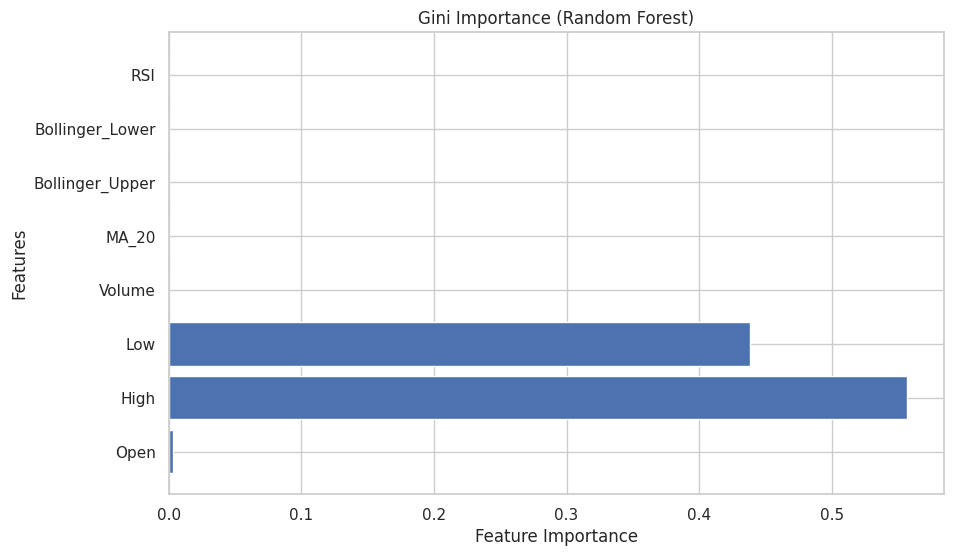

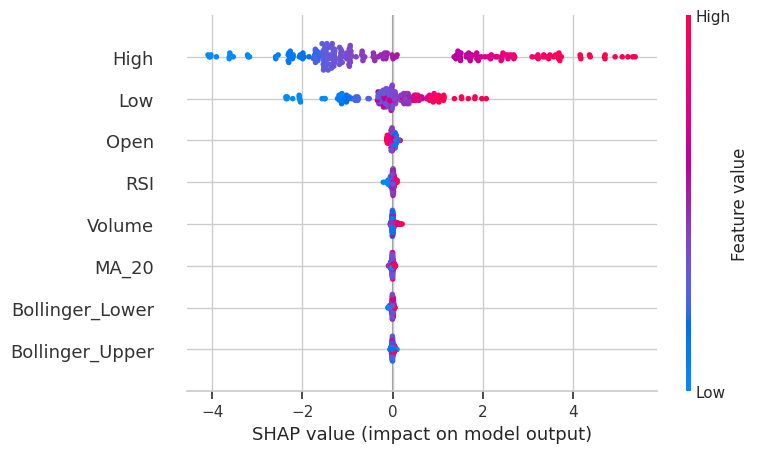

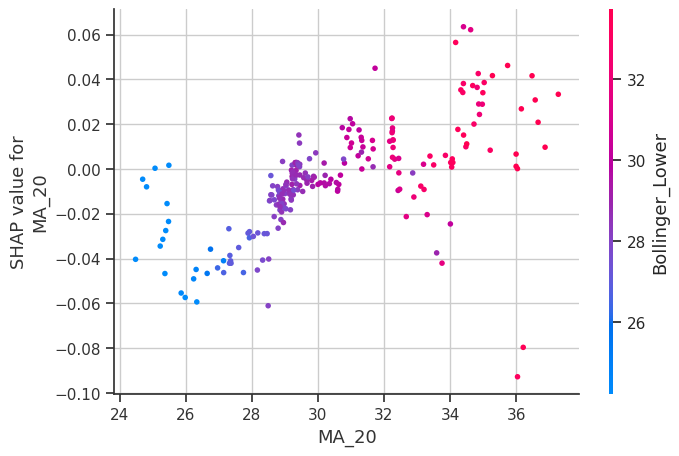

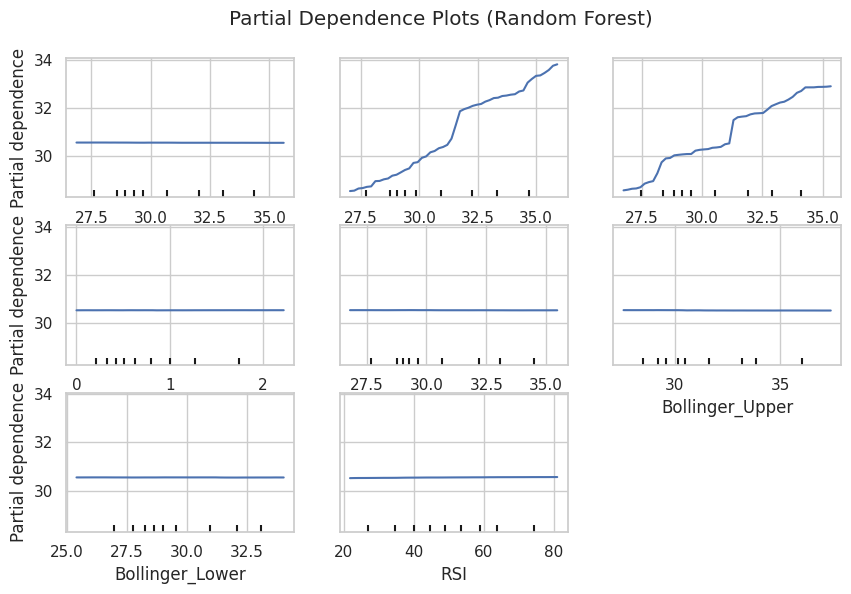

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap # import the installed package
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay # import the PartialDependenceDisplay class
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('stock_data_with_indicators.csv')

# Prepare features and target
features = ['Open', 'High', 'Low', 'Volume', 'MA_20', 'Bollinger_Upper', 'Bollinger_Lower', 'RSI']
target = 'Close'

X = df[features].dropna()
y = df[target].loc[X.index]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Gini Importance using Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importance (Gini importance)
gini_importance = rf_model.feature_importances_

# Plot Gini importance
plt.figure(figsize=(10, 6))
plt.barh(features, gini_importance)
plt.title("Gini Importance (Random Forest)")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

# 2. SHAP (SHapley Additive exPlanations) values using XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Create SHAP explainer for XGBoost
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

# Plot SHAP summary plot
shap.summary_plot(shap_values, X_test, feature_names=features)

# Plot SHAP dependence plot for a specific feature (e.g., MA_20)
# Access the values of the Explanation object
shap.dependence_plot('MA_20', shap_values.values, X_test)

# 3. Partial Dependence Plots (PDP)
fig, ax = plt.subplots(figsize=(10, 6))
# Use PartialDependenceDisplay.from_estimator instead of plot_partial_dependence
display = PartialDependenceDisplay.from_estimator(
    rf_model, X_train, features, grid_resolution=50, ax=ax
)
plt.suptitle('Partial Dependence Plots (Random Forest)')
plt.subplots_adjust(top=0.9)
plt.show()

Hybrid Models

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from keras.models import Sequential
from keras.layers import LSTM, Dense
import xgboost as xgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('stock_data_with_indicators.csv')

# Prepare data
df['Returns'] = df['Close'].pct_change()  # Log returns as the target variable
df = df.dropna()

# Split data into training and test sets
train_size = int(len(df) * 0.8)
train, test = df['Close'][:train_size], df['Close'][train_size:]

# Ensure that the series has enough length before creating the dataset
def create_dataset(series, time_step=1):
    dataX, dataY = [], []
    # Check if the series has enough data points for the time step
    if len(series) <= time_step:
        return np.array(dataX), np.array(dataY) # Return empty arrays if not enough data
    for i in range(len(series) - time_step):
        a = series[i:(i + time_step)]
        dataX.append(a)
        dataY.append(series[i + time_step])
    return np.array(dataX), np.array(dataY)

### LSTM-XGBoost Hybrid Model ###

# Step 1: LSTM model
X_train_lstm, y_train_lstm = create_dataset(train.values, time_step)
X_test_lstm, y_test_lstm = create_dataset(test.values, time_step)

# Reshape for LSTM
X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], X_train_lstm.shape[1], 1)
X_test_lstm = X_test_lstm.reshape(X_test_lstm.shape[0], X_test_lstm.shape[1], 1)

# Train the LSTM model again (or reuse if already trained)
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32, verbose=1)

# Get LSTM predictions
lstm_train_pred = lstm_model.predict(X_train_lstm)
lstm_test_pred = lstm_model.predict(X_test_lstm)

# Step 2: XGBoost on LSTM outputs (residual learning)
X_train_xgb = lstm_train_pred
X_test_xgb = lstm_test_pred
y_train_xgb = y_train_lstm
y_test_xgb = y_test_lstm

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
xgb_model.fit(X_train_xgb, y_train_xgb)

# Make predictions
xgb_pred = xgb_model.predict(X_test_xgb)

# Final hybrid prediction: LSTM + XGBoost
hybrid_lstm_xgb_pred = lstm_test_pred[:len(xgb_pred)] + xgb_pred.reshape(-1,1)
print(hybrid_lstm_xgb_pred)
# Reshape xgb_pred to ensure proper addition

# Compute metrics for LSTM-XGBoost
print("LSTM-XGBoost Model Performance:")
compute_metrics(test[:len(hybrid_lstm_xgb_pred)], hybrid_lstm_xgb_pred.flatten()) # Flatten the 2D array to 1D

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.1999
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.9997
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.6223
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.3055
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.7368
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.3528
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.9106
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.0551
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.3706
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.1765
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.4778
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.2007
Epoch 13/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.0419
Epoch 14/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.1941
Epoch 15/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.1827
Epoch 16/20
29/2

(916.5895599141028,
 30.275230138086528,
 30.271453465734208,
 97.15833825884557,
 -208.1638783275538)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  916
Model:                 ARIMA(5, 1, 3)   Log Likelihood                -341.128
Date:                Mon, 16 Sep 2024   AIC                            700.257
Time:                        18:44:25   BIC                            743.627
Sample:                             0   HQIC                           716.811
                                - 916                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6266      0.395     -1.587      0.112      -1.400       0.147
ar.L2          0.5377      0.228      2.357      0.018       0.091       0.985
ar.L3          0.4052      0.22

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


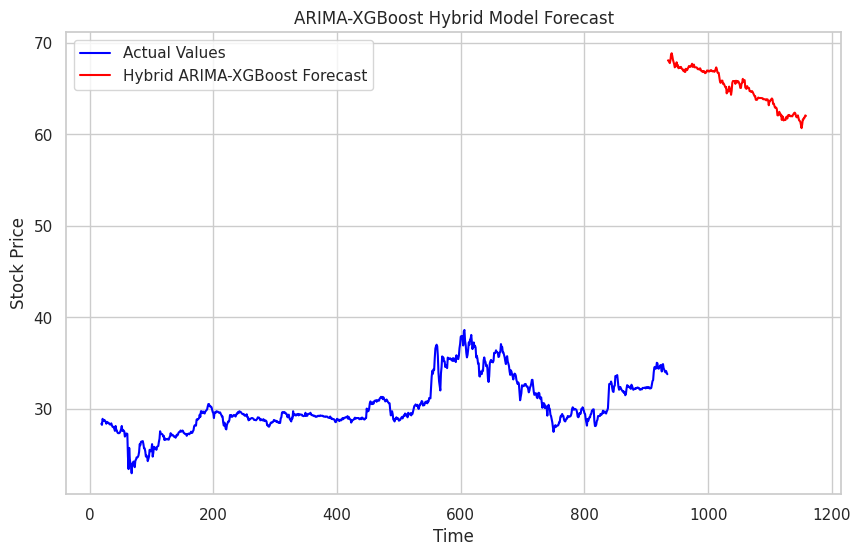

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# Load dataset
df = pd.read_csv('stock_data_with_indicators.csv')

# Prepare the data
df['Returns'] = df['Close'].pct_change()  # Log returns as the target variable
df = df.dropna()

# Split data into training and test sets
train_size = int(len(df) * 0.8)
train, test = df['Close'][:train_size], df['Close'][train_size:]

### Step 1: ARIMA Model ###

# ARIMA model to capture linear trend
arima_model = ARIMA(train, order=(5, 1, 3))  # Adjust ARIMA parameters as needed
arima_fit = arima_model.fit()

# Print ARIMA model summary
print("ARIMA Model Summary:")
print(arima_fit.summary())

# Get ARIMA residuals (non-linear component)
train_residuals = arima_fit.resid

### Step 2: XGBoost Model for residuals ###

# Prepare data for XGBoost
time_step = 5

# Create dataset from residuals
def create_dataset(series, time_step=1):
    dataX, dataY = [], []
    for i in range(len(series) - time_step):
        a = series[i:(i + time_step)]
        dataX.append(a)
        dataY.append(series[i + time_step])
    return np.array(dataX), np.array(dataY)

# Create datasets for XGBoost
X_train_xgb, y_train_xgb = create_dataset(train_residuals.values, time_step)
X_test_xgb, y_test_xgb = create_dataset(test.values, time_step)

# Train XGBoost on residuals
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
xgb_model.fit(X_test_xgb, y_test_xgb)

# Predict residuals on test set
xgb_pred_residuals = xgb_model.predict(X_test_xgb)

### Step 3: Final Hybrid Forecast (ARIMA + XGBoost) ###

# Get ARIMA predictions for test set
arima_pred = arima_fit.forecast(steps=len(test))

# Final hybrid predictions (ARIMA + XGBoost residuals)
hybrid_pred = arima_pred[:len(xgb_pred_residuals)] + xgb_pred_residuals

### Step 4: Evaluate the Model ###

# Define evaluation metrics
def compute_metrics(true, predicted):
    mse = mean_squared_error(true, predicted)
    mae = mean_absolute_error(true, predicted)
    r2 = r2_score(true, predicted)
    return mse, mae, r2

# Compute evaluation metrics
mse, mae, r2 = compute_metrics(test[:len(hybrid_pred)], hybrid_pred)

# Print evaluation metrics
print("\nARIMA-XGBoost Hybrid Model Performance:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Print Predicted values
print("\nPredicted values:\n", hybrid_pred)

### Step 5: Plot Forecast ###

plt.figure(figsize=(10, 6))
plt.plot(train.index, train.values, label="Actual Values", color='blue')
plt.plot(test.index[:len(hybrid_pred)], hybrid_pred, label="Hybrid ARIMA-XGBoost Forecast", color='red')
plt.title("ARIMA-XGBoost Hybrid Model Forecast")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

Linear Regression Coefficients: [-5.06457931e-01  8.04347806e-01  6.82121601e-01 -5.88379900e-10
  6.36534812e-03 -1.92537128e-03  1.46560675e-02  2.21992688e-03]
Linear Regression Model:
  RMSE: 0.14
  MSE: 0.02
  MAE: 0.10
  MAPE: 0.32%
  R-squared: 1.00

Random Forest Feature Importances: [2.86498163e-03 5.56872922e-01 4.38539683e-01 4.07858684e-04
 2.61937735e-04 3.10702391e-04 3.38268326e-04 4.03645576e-04]
Random Forest Model:
  RMSE: 0.07
  MSE: 0.00
  MAE: 0.04
  MAPE: 0.14%
  R-squared: 1.00

XGBoost Model Parameters: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_oneho

<ipython-input-58-17909206c398>:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(df.select_dtypes(include=np.number).mean(), inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                       │ (None, 50)                  │          11,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 35,555 (138.89 KB)

 Trainable params: 11,851 (46.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,704 (92.60 KB)

None
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
LSTM Model:
  RMSE: 223528.06
  MSE: 49964793474.69
  MAE: 90215.55
  MAPE: 297364.70%
  R-squared: -6572234236.53



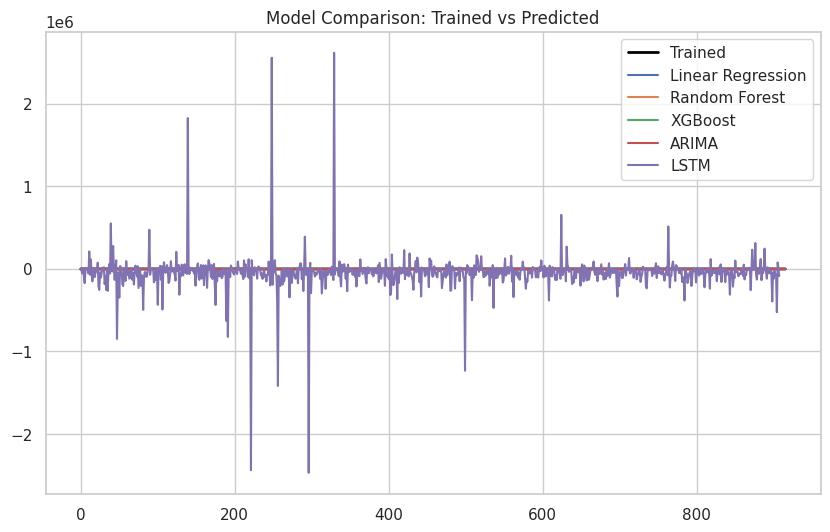

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Load dataset
df = pd.read_csv('stock_data_with_indicators.csv')  # Ensure your dataset contains all necessary indicators

# Prepare features and target
features = ['Open', 'High', 'Low', 'Volume', 'MA_20', 'Bollinger_Upper', 'Bollinger_Lower', 'RSI']
target = 'Close'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a function to evaluate and print model metrics
def evaluate_model(y_train, y_pred, model_name):
    mse = mean_squared_error(y_train, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_train, y_pred)
    mape = np.mean(np.abs((y_train - y_pred) / y_train)) * 100
    r2 = r2_score(y_train, y_pred)

    print(f"{model_name} Model:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R-squared: {r2:.2f}")
    print()

# 1. Linear Multiple Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
print("Linear Regression Coefficients:", lin_reg.coef_)
y_pred_lin_reg = lin_reg.predict(X_test)
evaluate_model(y_test, y_pred_lin_reg, 'Linear Regression')

# 2. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Feature Importances:", rf_model.feature_importances_)
y_pred_rf = rf_model.predict(X_train) # Predict on X_test
evaluate_model(y_train, y_pred_rf, 'Random Forest')

# 3. XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=1000, random_state=42)
xgb_model.fit(X_train, y_train)
print("XGBoost Model Parameters:", xgb_model.get_params())
y_pred_xgb = xgb_model.predict(X_train)
evaluate_model(y_train, y_pred_xgb, 'XGBoost')

# 4. ARIMA (Using just the 'Close' series, handle this separately)
# Prepare ARIMA data
y_test_arima = y_test.values
y_train_arima = y_train.values

# Fit ARIMA model (Example with (5,1,0) order, tune as necessary)
arima_model = ARIMA(y_train_arima, order=(5,1,0))
arima_fit = arima_model.fit()
# Summary of the ARIMA model
print(arima_fit.summary())

# Make ARIMA predictions
arima_pred = arima_fit.forecast(steps=len(y_train_arima))
evaluate_model(y_train_arima, arima_pred, 'ARIMA')

# Check for NaNs in the test data and predicted data
print("NaNs in y_test_lstm:", np.isnan(y_test_lstm).sum())
print("NaNs in y_pred_lstm:", np.isnan(y_pred_lstm).sum())

# Drop rows with NaN values from y_test_lstm and y_pred_lstm
y_test_lstm = y_test_lstm[~np.isnan(y_test_lstm)]
y_pred_lstm = y_pred_lstm[~np.isnan(y_pred_lstm)]

# Ensure both arrays have the same length before proceeding
if len(y_test_lstm) != len(y_pred_lstm):
    min_len = min(len(y_test_lstm), len(y_pred_lstm))
    y_test_lstm = y_test_lstm[:min_len]
    y_pred_lstm = y_pred_lstm[:min_len]

# Instead of using y_test_lstm to filter y_train_lstm, use y_train_lstm itself
y_train_lstm = y_train_lstm[~np.isnan(y_train_lstm)]

# Remove rows with missing values from the entire dataset
df = df.dropna()

# After dropping NaNs, prepare the data as usual
X = df[features]
y = df[target].loc[X.index]

# Impute missing values with the mean (or use other techniques)
df.fillna(df.select_dtypes(include=np.number).mean(), inplace=True)


# 5. LSTM (Long Short-Term Memory)
# Prepare LSTM data
def prepare_lstm_data(df, features, target, n_steps=1):
    X, y = [], []
    for i in range(len(df) - n_steps):
        X.append(df[features].iloc[i:i+n_steps].values)
        y.append(df[target].iloc[i+n_steps])
    return np.array(X), np.array(y)

n_steps = 10
X_lstm, y_lstm = prepare_lstm_data(df, features, target, n_steps)
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

# Define LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(n_steps, len(features))))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Train LSTM model
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=10, verbose=0)
print(lstm_model.summary())
y_pred_lstm = lstm_model.predict(X_train_lstm)

# Now evaluate the LSTM model with the corrected data
evaluate_model(y_train_lstm, y_pred_lstm, 'LSTM')

# Visualize Comparison (Optional)
def plot_comparison(models, y_test, predictions):
    plt.figure(figsize=(10,6))
    plt.plot(y_train.values, label='Trained', color='black', linewidth=2)
    for model_name, y_pred in predictions.items():
        plt.plot(y_pred, label=model_name)
    plt.legend()
    plt.title('Model Comparison: Trained vs Predicted')
    plt.show()

# Collect predictions for comparison plot
predictions = {
    'Linear Regression': y_pred_lin_reg,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'ARIMA': arima_pred,
    'LSTM': y_pred_lstm.flatten()
}

plot_comparison(predictions, y_train, predictions)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  916
Model:                 ARIMA(5, 1, 3)   Log Likelihood                -341.128
Date:                Mon, 16 Sep 2024   AIC                            700.257
Time:                        18:57:36   BIC                            743.627
Sample:                             0   HQIC                           716.811
                                - 916                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6266      0.395     -1.587      0.112      -1.400       0.147
ar.L2          0.5377      0.228      2.357      0.018       0.091       0.985
ar.L3          0.4052      0.22

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



ARIMA-LSTM Hybrid Model Performance:
Mean Squared Error (MSE): 11.3766
Mean Absolute Error (MAE): 2.6731
R-squared (R2): -1.5170

Predicted values:
 916     34.135995
917     33.768349
918     33.793454
919     33.804796
920     33.819827
          ...    
1140    33.843354
1141    33.843710
1142    33.844317
1143    33.843738
1144    33.843743
Name: predicted_mean, Length: 229, dtype: float64


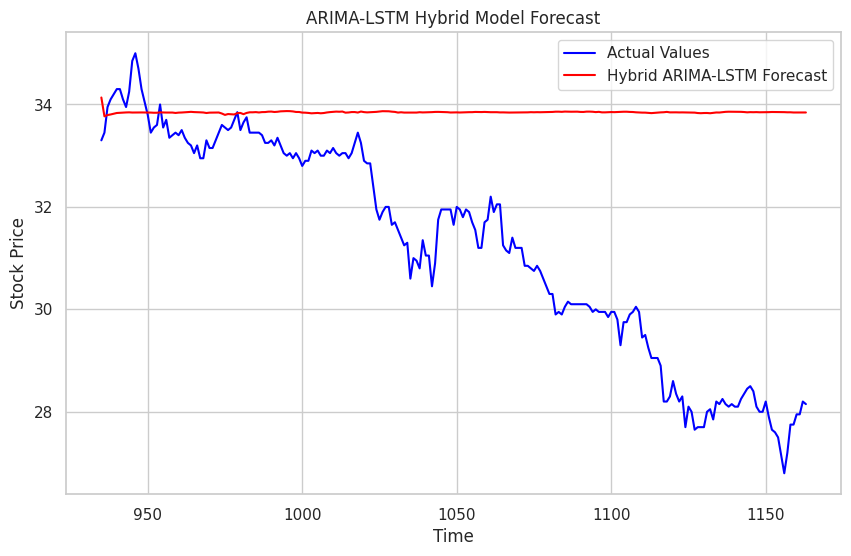

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv('stock_data_with_indicators.csv')  # Ensure your dataset contains all necessary indicators
df['Returns'] = df['Close'].pct_change()  # Use returns as the target variable
df = df.dropna()

# Prepare features and target
features = ['Open', 'High', 'Low', 'Volume', 'MA_20', 'Bollinger_Upper', 'Bollinger_Lower', 'RSI']
target = 'Close'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs


# Split data into training and test sets
train_size = int(len(df) * 0.8)
train, test = df['Close'][:train_size], df['Close'][train_size:]

### Step 1: ARIMA Model ###

# ARIMA model to capture linear trend
arima_model = ARIMA(train, order=(5, 1, 3))  # Adjust ARIMA parameters as needed
arima_fit = arima_model.fit()

# Print ARIMA model summary
print("ARIMA Model Summary:")
print(arima_fit.summary())

# Get ARIMA residuals (non-linear component)
train_residuals = arima_fit.resid

### Step 2: LSTM Model for Residuals ###

# Scaling the residuals for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_residuals = scaler.fit_transform(train_residuals.values.reshape(-1, 1))

# Create dataset for LSTM
def create_dataset(series, time_step=1):
    dataX, dataY = [], []
    for i in range(len(series) - time_step):
        a = series[i:(i + time_step)]
        dataX.append(a)
        dataY.append(series[i + time_step])
    return np.array(dataX), np.array(dataY)

# Create datasets for LSTM
time_step = 5
X_train_lstm, y_train_lstm = create_dataset(scaled_train_residuals, time_step)

# Reshape X to be [samples, time steps, features] for LSTM input
X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], X_train_lstm.shape[1], 1)

# Build LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
lstm_model.add(LSTM(50))
lstm_model.add(Dense(1))
lstm_model.compile(loss='mean_squared_error', optimizer='adam')

# Train the LSTM model
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=64, verbose=1)

# Predict residuals for the test set
scaled_test_residuals = scaler.transform(test.values.reshape(-1, 1))
X_test_lstm, y_test_lstm = create_dataset(scaled_test_residuals, time_step)
X_test_lstm = X_test_lstm.reshape(X_test_lstm.shape[0], X_test_lstm.shape[1], 1)

# LSTM predictions
lstm_pred_residuals = lstm_model.predict(X_train_lstm)
lstm_pred_residuals = scaler.inverse_transform(lstm_pred_residuals)  # Inverse scaling

### Step 3: Hybrid Forecast (ARIMA + LSTM) ###

# Get ARIMA predictions for the test set
arima_pred = arima_fit.forecast(steps=len(train))

# Final hybrid predictions (ARIMA + LSTM residuals)
hybrid_pred = arima_pred[:len(lstm_pred_residuals)] + lstm_pred_residuals.flatten()

### Step 4: Evaluate the Model ###

# Define evaluation metrics
def compute_metrics(true, predicted):
    mse = mean_squared_error(true, predicted)
    mae = mean_absolute_error(true, predicted)
    r2 = r2_score(true, predicted)
    return mse, mae, r2

# Compute evaluation metrics
mse, mae, r2 = compute_metrics(test[:len(hybrid_pred)], hybrid_pred[:len(test)])

# Print evaluation metrics
print("\nARIMA-LSTM Hybrid Model Performance:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Print predicted values
print("\nPredicted values:\n", hybrid_pred[:len(test)])

### Step 5: Plot Forecast ###

plt.figure(figsize=(10, 6))
plt.plot(test.index, test.values, label="Actual Values", color='blue')
# Change was made here to ensure both arrays have the same length
plt.plot(test.index, hybrid_pred[:len(test)], label="Hybrid ARIMA-LSTM Forecast", color='red')
plt.title("ARIMA-LSTM Hybrid Model Forecast")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


Hybrid LMR-RF Model Performance (Train Data):
Train MSE: 0.0633, Train RMSE: 0.2515, Train MAE: 0.1727, Train MAPE: 0.57%, Train R-squared: 0.9924

Hybrid LMR-RF Model Performance (Test Data):
Test MSE: 0.1221, Test RMSE: 0.3494, Test MAE: 0.2618, Test MAPE: 0.84%, Test R-squared: 0.9730


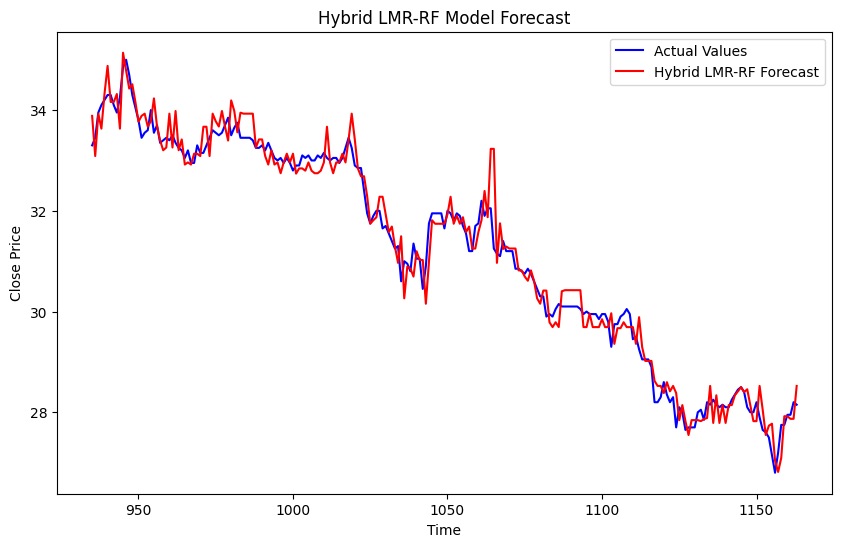


Predicted values (Test Set for 139 days):
 [33.88471141 33.08754243 33.92909716 33.63185189 34.31903623 34.87774756
 34.16102339 34.16102339 34.31903623 33.63185189 35.13897189 34.77661337
 34.42723164 34.51246926 34.16102339 33.76901661 33.88471141 33.92909716
 33.67364116 33.77797956 34.23213668 33.67364116 33.39578318 33.20252717
 33.25711846 33.92909716 33.25711846 33.98194355 33.20252717 33.41761383
 32.91893447 32.96102823 32.91893447 33.13393001 33.13393001 33.08754243
 33.66962121 33.66962121 33.08754243 33.92909716 33.77797956 33.67364116
 33.98194355 33.67364116 33.39578318 34.19273382 33.98194355 33.55773724
 33.94825259 33.92909716 33.92909716 33.92909716 33.92909716 33.25711846
 33.41761383 33.41761383 33.08754243 32.91893447 33.20252717 32.91893447
 32.96102823 32.74639706 32.96102823 33.13393001 32.96102823 33.13393001
 32.73826731 32.84191875 32.84191875 32.79700111 32.96102823 32.79700111
 32.74639706 32.74639706 32.79700111 32.96102823 33.66962121 32.96102823
 32.746

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('stock_data_with_indicators.csv')  # Ensure your dataset contains all necessary indicators
df['Returns'] = df['Close'].pct_change()  # Use returns as the target variable
df = df.dropna()

# Prepare features and target
features = ['Open', 'High', 'Low', 'Volume', 'MA_20', 'Bollinger_Upper', 'Bollinger_Lower', 'RSI']
target = 'Close'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs

# Feature Engineering
df['lag_1'] = df[target].shift(1)  # Create lagged feature
df.dropna(inplace=True)  # Drop missing values created by lagging

# Split the data into train and test sets
X = df[['lag_1']]  # Use lag feature as predictor
y = df[target]  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 1: Linear Multiple Regression (LMR) Model
lmr_model = LinearRegression()
lmr_model.fit(X_train, y_train)

# LMR Predictions
lmr_train_pred = lmr_model.predict(X_train)
lmr_test_pred = lmr_model.predict(X_test)

# Calculate residuals for Random Forest
train_residuals = y_train - lmr_train_pred

# Step 2: Random Forest Model (RF) for Residuals
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, train_residuals)

# RF Predictions for residuals
rf_train_pred_residuals = rf_model.predict(X_train)
rf_test_pred_residuals = rf_model.predict(X_test)

# Step 3: Hybrid Forecast (LMR + RF)
hybrid_train_pred = lmr_train_pred + rf_train_pred_residuals
hybrid_test_pred = lmr_test_pred + rf_test_pred_residuals

# Step 4: Evaluation Metrics
def compute_metrics(true, predicted):
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, predicted)
    mape = np.mean(np.abs((true - predicted) / true)) * 100
    r2 = r2_score(true, predicted)
    return mse, rmse, mae, mape, r2

# Metrics for training data
train_mse, train_rmse, train_mae, train_mape, train_r2 = compute_metrics(y_train, hybrid_train_pred)

# Metrics for test data
test_mse, test_rmse, test_mae, test_mape, test_r2 = compute_metrics(y_test, hybrid_test_pred)

# Print evaluation metrics for training data
print("\nHybrid LMR-RF Model Performance (Train Data):")
print(f"Train MSE: {train_mse:.4f}, Train RMSE: {train_rmse:.4f}, Train MAE: {train_mae:.4f}, Train MAPE: {train_mape:.2f}%, Train R-squared: {train_r2:.4f}")

# Print evaluation metrics for test data
print("\nHybrid LMR-RF Model Performance (Test Data):")
print(f"Test MSE: {test_mse:.4f}, Test RMSE: {test_rmse:.4f}, Test MAE: {test_mae:.4f}, Test MAPE: {test_mape:.2f}%, Test R-squared: {test_r2:.4f}")

# Step 5: Plot Forecast
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test.values, label="Actual Values", color='blue')
plt.plot(y_test.index, hybrid_test_pred, label="Hybrid LMR-RF Forecast", color='red')
plt.title("Hybrid LMR-RF Model Forecast")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# Print predicted values for the test set (for the next 139 days)
print("\nPredicted values (Test Set for 139 days):\n", hybrid_test_pred[:139])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving saudi_aramco_data.csv to saudi_aramco_data.csv


In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('saudi_aramco_data.csv')  # Ensure 'stock_data.csv' has columns: 'Open', 'High', 'Low', 'Close', 'Volume'

# Moving Average (MA)
def moving_average(df, window=20):
    df[f'MA_{window}'] = df['Close'].rolling(window=window).mean()

# Bollinger Bands
def bollinger_bands(df, window=20, num_std_dev=2):
    df['MA20'] = df['Close'].rolling(window=window).mean()
    df['Bollinger_Upper'] = df['MA20'] + (df['Close'].rolling(window=window).std() * num_std_dev)
    df['Bollinger_Lower'] = df['MA20'] - (df['Close'].rolling(window=window).std() * num_std_dev)

# Relative Strength Index (RSI)
def rsi(df, window=14):
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

# Apply the functions to the DataFrame
moving_average(df, window=20)
bollinger_bands(df, window=20, num_std_dev=2)
rsi(df, window=14)

# Print necessary parameters
print("Moving Averages:")
print(df[['Close', 'MA_20']].tail())  # Adjust the column name as necessary

print("\nBollinger Bands:")
print(df[['Close', 'MA20', 'Bollinger_Upper', 'Bollinger_Lower']].tail())

print("\nRelative Strength Index (RSI):")
print(df[['Close', 'RSI']].tail())

# Save the modified DataFrame to a new CSV file
df.to_csv('stock_data_with_indicators.csv', index=False)

Moving Averages:
          Close    MA_20
1159  27.750000  27.8875
1160  27.950001  27.8800
1161  27.950001  27.8725
1162  28.200001  27.8700
1163  28.150000  27.8600

Bollinger Bands:
          Close     MA20  Bollinger_Upper  Bollinger_Lower
1159  27.750000  27.8875        28.814791        26.960209
1160  27.950001  27.8800        28.802469        26.957532
1161  27.950001  27.8725        28.789862        26.955138
1162  28.200001  27.8700        28.783294        26.956706
1163  28.150000  27.8600        28.755369        26.964632

Relative Strength Index (RSI):
          Close        RSI
1159  27.750000  37.704930
1160  27.950001  42.857169
1161  27.950001  47.368432
1162  28.200001  53.333342
1163  28.150000  52.459006


Tested XGBoost Model Forecasted values for the next 139 days:
[29.201496 29.403769 29.370373 36.604404 29.286537 30.15018  31.649803
 26.675072 27.830433 29.903309 29.29939  29.208416 32.295338 28.783104
 33.617096 33.964653 25.847452 32.965553 29.259268 29.755974 30.878344
 29.378448 23.858425 28.748451 30.83544  30.89989  33.566116 28.904345
 28.93352  27.518198 33.829216 31.6167   33.444088 33.451736 29.212759
 29.114784 29.605362 28.124928 25.773817 23.869118 33.262306 34.053864
 28.944174 27.893723 24.416492 29.067255 33.46386  29.882723 28.952503
 31.797195 32.30499  29.244017 37.624573 29.908222 35.47703  35.124275
 28.64     34.198032 30.016867 32.392384 35.183056 24.970308 27.092684
 31.186895 27.711119 29.671352 29.302225 32.418434 32.69321  31.080004
 27.311216 30.032598 34.08712  29.976631 29.4843   29.579016 30.476643
 33.9928   35.23604  32.087788 27.087818 29.86728  29.394316 29.180658
 33.132378 27.210732 35.93547  35.172424 32.20158  27.521872 26.56718
 28.930666 27.29

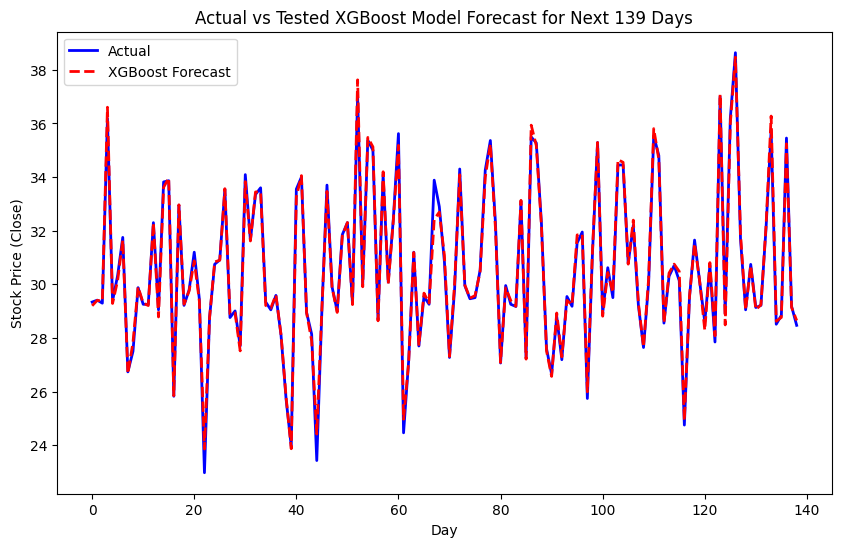

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# Load dataset
df = pd.read_csv('stock_data_with_indicators.csv')  # Ensure your dataset contains all necessary indicators

# Prepare features and target
features = ['Open', 'High', 'Low', 'Volume', 'MA_20', 'Bollinger_Upper', 'Bollinger_Lower', 'RSI']
target = 'Close'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. XGBoost Model
xgb_model = xgb.XGBRegressor(n_estimators=1000, random_state=42)
xgb_model.fit(X_train, y_train)

# Forecast for the next 139 days
# Assuming you have 139 new data points, otherwise extend X_test for demonstration
forecast_period = 139
X_forecast = X_test[:forecast_period]  # Use part of the test set for simplicity
y_pred_xgb_forecast = xgb_model.predict(X_forecast)

# Print the forecasted values for the next 139 days
print("Tested XGBoost Model Forecasted values for the next 139 days:")
print(y_pred_xgb_forecast)

# Evaluate the model
def evaluate_model(y_test, y_pred, model_name):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name} Model:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R-squared: {r2:.2f}")
    print()

# Evaluate the forecasted values
evaluate_model(y_test[:forecast_period], y_pred_xgb_forecast, 'XGBoost')

# Plot actual vs forecasted values
plt.figure(figsize=(10,6))
plt.plot(y_test[:forecast_period].values, label='Actual', color='blue', linewidth=2)
plt.plot(y_pred_xgb_forecast, label='XGBoost Forecast', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Tested XGBoost Model Forecast for Next 139 Days')
plt.xlabel('Day')
plt.ylabel('Stock Price (Close)')
plt.legend()
plt.show()

Trained XGBoost Model Forecasted values for the next 139 days:
[35.727665 30.180384 35.537155 26.446009 32.85339  26.489254 29.303278
 30.908928 28.469223 28.10085  35.826744 37.60343  29.906527 28.967278
 32.72743  33.24933  28.135439 29.62877  30.955824 32.951336 33.454006
 29.251848 28.885996 29.008043 34.049267 30.101667 35.136612 32.45344
 29.452585 29.09239  29.460241 28.925596 28.677904 34.101326 35.05194
 29.008688 29.334908 29.091555 31.683857 34.300278 29.259586 28.75898
 29.09059  30.620922 30.953644 30.826038 33.298088 33.55066  28.926413
 27.643677 29.174263 23.966393 26.694448 24.380497 28.717825 29.258625
 26.86181  29.134014 32.799404 32.505535 24.794031 33.7278   29.5019
 29.500792 33.699066 33.251087 29.044785 29.295288 32.499714 32.72687
 35.620487 28.272985 32.198895 32.765    28.819164 30.90947  24.917068
 33.65002  25.949594 30.18184  29.271242 32.547955 28.721148 36.18174
 31.02729  32.72685  29.009333 28.136543 29.293756 26.901014 33.227196
 31.724854 29.49973  

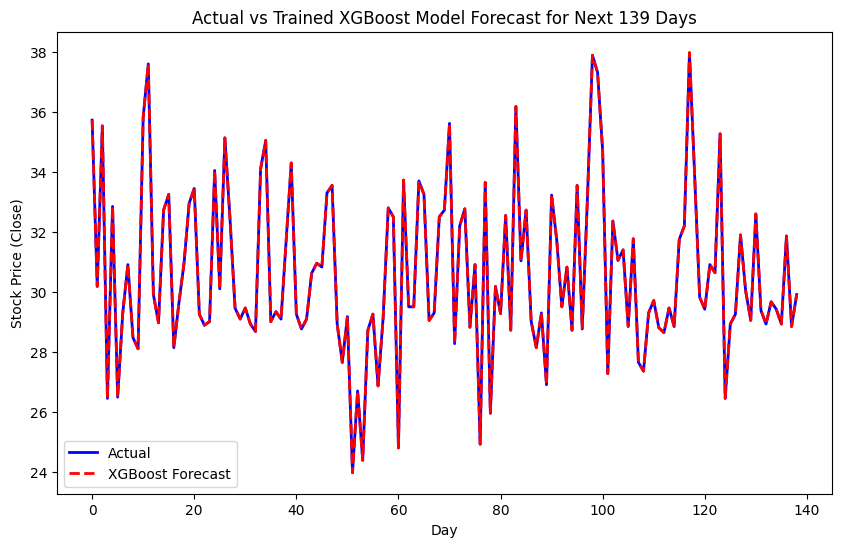

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# Load dataset
df = pd.read_csv('stock_data_with_indicators.csv')  # Ensure your dataset contains all necessary indicators

# Prepare features and target
features = ['Open', 'High', 'Low', 'Volume', 'MA_20', 'Bollinger_Upper', 'Bollinger_Lower', 'RSI']
target = 'Close'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. XGBoost Model
xgb_model = xgb.XGBRegressor(n_estimators=1000, random_state=42)
xgb_model.fit(X_train, y_train)

# Forecast for the next 139 days
# Assuming you have 139 new data points, otherwise extend X_test for demonstration
forecast_period = 139
X_forecast = X_train[:forecast_period]  # Use part of the test set for simplicity
y_pred_xgb_forecast = xgb_model.predict(X_forecast)

# Print the forecasted values for the next 139 days
print("Trained XGBoost Model Forecasted values for the next 139 days:")
print(y_pred_xgb_forecast)

# Evaluate the model
def evaluate_model(y_train, y_pred, model_name):
    mse = mean_squared_error(y_train, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_train, y_pred)
    mape = np.mean(np.abs((y_train - y_pred) / y_train)) * 100
    r2 = r2_score(y_train, y_pred)

    print(f"{model_name} Model:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R-squared: {r2:.2f}")
    print()

# Evaluate the forecasted values
evaluate_model(y_train[:forecast_period], y_pred_xgb_forecast, 'XGBoost')

# Plot actual vs forecasted values
plt.figure(figsize=(10,6))
plt.plot(y_train[:forecast_period].values, label='Actual', color='blue', linewidth=2)
plt.plot(y_pred_xgb_forecast, label='XGBoost Forecast', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Trained XGBoost Model Forecast for Next 139 Days')
plt.xlabel('Day')
plt.ylabel('Stock Price (Close)')
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Usin

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  916
Model:                 ARIMA(5, 1, 3)   Log Likelihood                -341.128
Date:                Thu, 03 Oct 2024   AIC                            700.257
Time:                        11:41:32   BIC                            743.627
Sample:                             0   HQIC                           716.811
                                - 916                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6266      0.395     -1.587      0.112      -1.400       0.147
ar.L2          0.5377      0.228      2.357      0.018       0.091       0.985
ar.L3          0.4052      0.22

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


ValueError: x and y must have same first dimension, but have shapes (229,) and (911,)

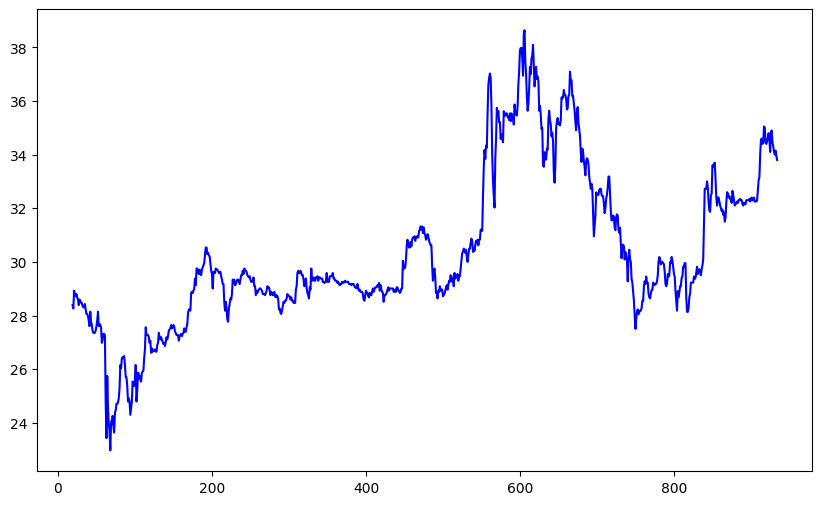

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# Load dataset
df = pd.read_csv('stock_data_with_indicators.csv')

# Prepare the data
df['Returns'] = df['Close'].pct_change()  # Log returns as the target variable
df = df.dropna()

# Split data into training and test sets
train_size = int(len(df) * 0.8)
train, test = df['Close'][:train_size], df['Close'][train_size:]

### Step 1: ARIMA Model ###

# ARIMA model to capture linear trend
arima_model = ARIMA(train, order=(5, 1, 3))  # Adjust ARIMA parameters as needed
arima_fit = arima_model.fit()

# Print ARIMA model summary
print("ARIMA Model Summary:")
print(arima_fit.summary())

# Get ARIMA residuals (non-linear component)
train_residuals = arima_fit.resid

### Step 2: XGBoost Model for residuals ###

# Prepare data for XGBoost
time_step = 5

# Create dataset from residuals
def create_dataset(series, time_step=1):
    dataX, dataY = [], []
    for i in range(len(series) - time_step):
        a = series[i:(i + time_step)]
        dataX.append(a)
        dataY.append(series[i + time_step])
    return np.array(dataX), np.array(dataY)

# Create datasets for XGBoost
X_train_xgb, y_train_xgb = create_dataset(train_residuals.values, time_step)
X_test_xgb, y_test_xgb = create_dataset(test.values, time_step)

# Train XGBoost on residuals
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
xgb_model.fit(X_train_xgb, y_train_xgb)

# Predict residuals on test set
xgb_pred_residuals = xgb_model.predict(X_train_xgb)

### Step 3: Final Hybrid Forecast (ARIMA + XGBoost) ###

# Get ARIMA predictions for test set
arima_pred = arima_fit.forecast(steps=len(train))

# Final hybrid predictions (ARIMA + XGBoost residuals)
hybrid_pred = arima_pred[:len(xgb_pred_residuals)] + xgb_pred_residuals

### Step 4: Evaluate the Model ###

# Define evaluation metrics
def compute_metrics(true, predicted):
    mse = mean_squared_error(true, predicted)
    mae = mean_absolute_error(true, predicted)
    r2 = r2_score(true, predicted)
    return mse, mae, r2

# Compute evaluation metrics
mse, mae, r2 = compute_metrics(train[:len(hybrid_pred)], hybrid_pred)

# Print evaluation metrics
print("\nARIMA-XGBoost Hybrid Model Performance:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Print Predicted values
print("\nPredicted values:\n", hybrid_pred)

### Step 5: Plot Forecast ###

plt.figure(figsize=(10, 6))
plt.plot(train.index, train.values, label="Actual Values", color='blue')
plt.plot(test.index[:len(hybrid_pred)], hybrid_pred, label="Hybrid ARIMA-XGBoost Forecast", color='red')
plt.title("ARIMA-XGBoost Hybrid Model Forecast")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving saudi_aramco_data.csv to saudi_aramco_data.csv


In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('saudi_aramco_data.csv')  # Ensure 'stock_data.csv' has columns: 'Open', 'High', 'Low', 'Close', 'Volume'

# Moving Average (MA)
def moving_average(df, window=20):
    df[f'MA_{window}'] = df['Close'].rolling(window=window).mean()

# Bollinger Bands
def bollinger_bands(df, window=20, num_std_dev=2):
    df['MA20'] = df['Close'].rolling(window=window).mean()
    df['Bollinger_Upper'] = df['MA20'] + (df['Close'].rolling(window=window).std() * num_std_dev)
    df['Bollinger_Lower'] = df['MA20'] - (df['Close'].rolling(window=window).std() * num_std_dev)

# Relative Strength Index (RSI)
def rsi(df, window=14):
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

# Apply the functions to the DataFrame
moving_average(df, window=20)
bollinger_bands(df, window=20, num_std_dev=2)
rsi(df, window=14)

# Print necessary parameters
print("Moving Averages:")
print(df[['Close', 'MA_20']].tail())  # Adjust the column name as necessary

print("\nBollinger Bands:")
print(df[['Close', 'MA20', 'Bollinger_Upper', 'Bollinger_Lower']].tail())

print("\nRelative Strength Index (RSI):")
print(df[['Close', 'RSI']].tail())

# Save the modified DataFrame to a new CSV file
df.to_csv('stock_data_with_indicators.csv', index=False)

Moving Averages:
          Close    MA_20
1159  27.750000  27.8875
1160  27.950001  27.8800
1161  27.950001  27.8725
1162  28.200001  27.8700
1163  28.150000  27.8600

Bollinger Bands:
          Close     MA20  Bollinger_Upper  Bollinger_Lower
1159  27.750000  27.8875        28.814791        26.960209
1160  27.950001  27.8800        28.802469        26.957532
1161  27.950001  27.8725        28.789862        26.955138
1162  28.200001  27.8700        28.783294        26.956706
1163  28.150000  27.8600        28.755369        26.964632

Relative Strength Index (RSI):
          Close        RSI
1159  27.750000  37.704930
1160  27.950001  42.857169
1161  27.950001  47.368432
1162  28.200001  53.333342
1163  28.150000  52.459006


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 880.9268
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 585.6395
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 334.9328
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 258.0151
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 206.7156
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 166.2585
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 136.6004
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 106.9593
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 88.7389
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 72.6208
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 58.8113
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 45.4018
Epoch 13/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37.0545
Epoch 14/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30.2328
Epoch 15/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25.0207
Epoch 1

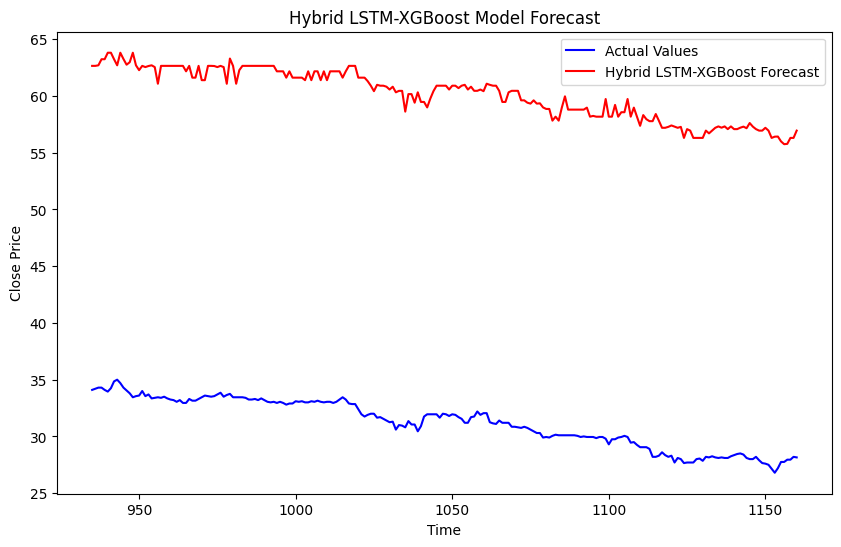

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.models import Sequential
from keras.layers import LSTM, Dense
import xgboost as xgb
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('stock_data_with_indicators.csv')

# Prepare data
df['Returns'] = df['Close'].pct_change()  # Log returns as the target variable
df = df.dropna()

# Split data into training and test sets
train_size = int(len(df) * 0.8)
train, test = df['Close'][:train_size], df['Close'][train_size:]

# Ensure that the series has enough length before creating the dataset
def create_dataset(series, time_step=1):
    dataX, dataY = [], []
    for i in range(len(series) - time_step):
        a = series[i:(i + time_step)]
        dataX.append(a)
        dataY.append(series[i + time_step])
    return np.array(dataX), np.array(dataY)

### LSTM-XGBoost Hybrid Model ###

# Step 1: LSTM model
time_step = 3  # You can adjust the time step value
X_train_lstm, y_train_lstm = create_dataset(train.values, time_step)
X_test_lstm, y_test_lstm = create_dataset(test.values, time_step)

# Reshape for LSTM
X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], X_train_lstm.shape[1], 1)
X_test_lstm = X_test_lstm.reshape(X_test_lstm.shape[0], X_test_lstm.shape[1], 1)

# Define the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)))
lstm_model.add(LSTM(units=50))
lstm_model.add(Dense(1))

# Compile the model
lstm_model.compile(loss='mean_squared_error', optimizer='adam')

# Train the LSTM model
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32, verbose=1)

# Get LSTM predictions
lstm_train_pred = lstm_model.predict(X_train_lstm)
lstm_test_pred = lstm_model.predict(X_test_lstm)

# Step 2: XGBoost on LSTM outputs (residual learning)
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
xgb_model.fit(lstm_train_pred, y_train_lstm)

# Make predictions
xgb_train_pred = xgb_model.predict(lstm_train_pred)
xgb_test_pred = xgb_model.predict(lstm_test_pred)

# Final hybrid prediction: LSTM + XGBoost
hybrid_train_pred = lstm_train_pred.flatten() + xgb_train_pred
hybrid_test_pred = lstm_test_pred.flatten() + xgb_test_pred

# Step 3: Evaluation Metrics ###

# Define evaluation metrics
def compute_metrics(true, predicted):
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, predicted)
    mape = np.mean(np.abs((true - predicted) / true)) * 100
    r2 = r2_score(true, predicted)
    return rmse, mse, mae, mape, r2

# Compute evaluation metrics for the LSTM-XGBoost model on train and test data
train_rmse, train_mse, train_mae, train_mape, train_r2 = compute_metrics(y_train_lstm, hybrid_train_pred)
test_rmse, test_mse, test_mae, test_mape, test_r2 = compute_metrics(y_test_lstm, hybrid_test_pred)

# Print evaluation metrics
print("\nLSTM-XGBoost Model Performance (Train Data):")
print(f"RMSE: {train_rmse:.4f}, MSE: {train_mse:.4f}, MAE: {train_mae:.4f}, MAPE: {train_mape:.2f}%, R²: {train_r2:.4f}")
print("\nLSTM-XGBoost Model Performance (Test Data):")
print(f"RMSE: {test_rmse:.4f}, MSE: {test_mse:.4f}, MAE: {test_mae:.4f}, MAPE: {test_mape:.2f}%, R²: {test_r2:.4f}")

# Step 4: Plot the predictions ###
plt.figure(figsize=(10, 6))
plt.plot(test.index[:len(y_test_lstm)], y_test_lstm, label="Actual Values", color='blue')
plt.plot(test.index[:len(y_test_lstm)], hybrid_test_pred, label="Hybrid LSTM-XGBoost Forecast", color='red')
plt.title("Hybrid LSTM-XGBoost Model Forecast")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()


Hybrid LMR-RF Model Performance (Train Data):
Train MSE: 0.0633, Train RMSE: 0.2515, Train MAE: 0.1727, Train MAPE: 0.57%, Train R-squared: 0.9924

Hybrid LMR-RF Model Performance (Test Data):
Test MSE: 0.1221, Test RMSE: 0.3494, Test MAE: 0.2618, Test MAPE: 0.84%, Test R-squared: 0.9730


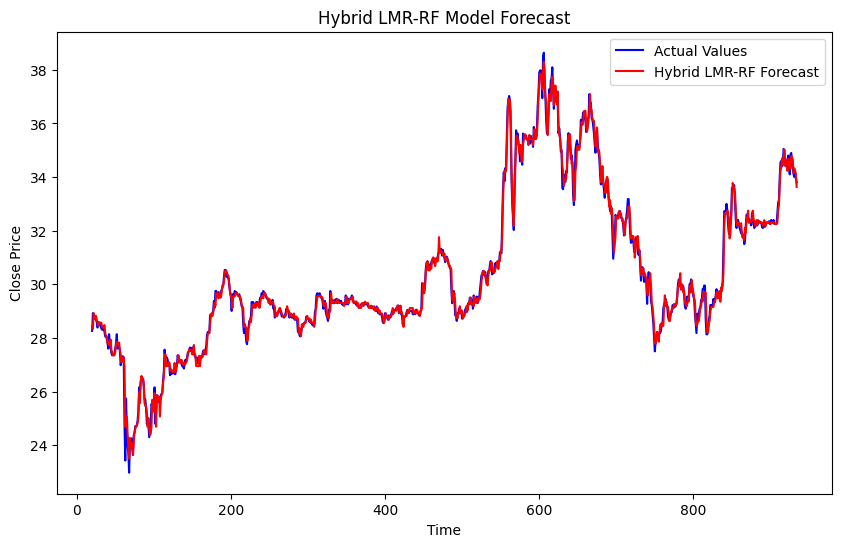


Predicted values (Train Set for 139 days):
 [28.44654624 28.351705   28.92487265 28.80279474 28.72280089 28.82529632
 28.68114959 28.59296806 28.44654624 28.59296806 28.56868885 28.56829809
 28.56829809 28.41198204 28.38757338 28.38757338 28.4789125  28.18449524
 28.0695168  28.0695168  27.79926235 27.85768245 27.73688093 27.77545466
 27.93959695 27.54327343 27.47995073 27.35607997 27.35607997 27.35607997
 27.47995073 27.73688093 27.85768245 27.77545466 27.73688093 27.83030228
 27.54327343 27.38396583 27.09087788 27.18388558 27.27638688 27.27638688
 26.95140127 24.68957912 25.09064139 25.07157972 24.4313872  23.92381426
 23.50185941 24.26973765 23.98054271 23.92381426 24.07413316 23.67140248
 24.11577793 24.48726233 24.61524121 24.71700981 24.71700981 24.83374373
 25.00916379 25.96634933 25.57044513 26.3144538  26.58428342 26.47901482
 26.47901482 26.32071771 25.57044513 25.46900448 25.46900448 25.25327302
 24.68957912 25.00916379 24.68957912 24.36941447 24.4313872  24.68957912
 25.69

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('stock_data_with_indicators.csv')  # Ensure your dataset contains all necessary indicators
df['Returns'] = df['Close'].pct_change()  # Use returns as the target variable
df = df.dropna()

# Prepare features and target
features = ['Open', 'High', 'Low', 'Volume', 'MA_20', 'Bollinger_Upper', 'Bollinger_Lower', 'RSI']
target = 'Close'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs

# Feature Engineering
df['lag_1'] = df[target].shift(1)  # Create lagged feature
df.dropna(inplace=True)  # Drop missing values created by lagging

# Split the data into train and test sets
X = df[['lag_1']]  # Use lag feature as predictor
y = df[target]  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 1: Linear Multiple Regression (LMR) Model
lmr_model = LinearRegression()
lmr_model.fit(X_train, y_train)

# LMR Predictions
lmr_train_pred = lmr_model.predict(X_train)
lmr_test_pred = lmr_model.predict(X_test)

# Calculate residuals for Random Forest
train_residuals = y_train - lmr_train_pred

# Step 2: Random Forest Model (RF) for Residuals
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, train_residuals)

# RF Predictions for residuals
rf_train_pred_residuals = rf_model.predict(X_train)
rf_test_pred_residuals = rf_model.predict(X_test)

# Step 3: Hybrid Forecast (LMR + RF)
hybrid_train_pred = lmr_train_pred + rf_train_pred_residuals
hybrid_test_pred = lmr_test_pred + rf_test_pred_residuals

# Step 4: Evaluation Metrics
def compute_metrics(true, predicted):
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, predicted)
    mape = np.mean(np.abs((true - predicted) / true)) * 100
    r2 = r2_score(true, predicted)
    return mse, rmse, mae, mape, r2

# Metrics for training data
train_mse, train_rmse, train_mae, train_mape, train_r2 = compute_metrics(y_train, hybrid_train_pred)

# Metrics for test data
test_mse, test_rmse, test_mae, test_mape, test_r2 = compute_metrics(y_test, hybrid_test_pred)

# Print evaluation metrics for training data
print("\nHybrid LMR-RF Model Performance (Train Data):")
print(f"Train MSE: {train_mse:.4f}, Train RMSE: {train_rmse:.4f}, Train MAE: {train_mae:.4f}, Train MAPE: {train_mape:.2f}%, Train R-squared: {train_r2:.4f}")

# Print evaluation metrics for test data
print("\nHybrid LMR-RF Model Performance (Test Data):")
print(f"Test MSE: {test_mse:.4f}, Test RMSE: {test_rmse:.4f}, Test MAE: {test_mae:.4f}, Test MAPE: {test_mape:.2f}%, Test R-squared: {test_r2:.4f}")

# Step 5: Plot Forecast
plt.figure(figsize=(10, 6))
plt.plot(y_train.index, y_train.values, label="Actual Values", color='blue')
plt.plot(y_train.index, hybrid_train_pred, label="Hybrid LMR-RF Forecast", color='red')
plt.title("Hybrid LMR-RF Model Forecast")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# Print predicted values for the test set (for the next 139 days)
print("\nPredicted values (Train Set for 139 days):\n", hybrid_train_pred[:139])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving saudi_aramco_data.csv to saudi_aramco_data.csv


In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('saudi_aramco_data.csv')  # Ensure 'stock_data.csv' has columns: 'Open', 'High', 'Low', 'Close', 'Volume'

# Moving Average (MA)
def moving_average(df, window=20):
    df[f'MA_{window}'] = df['Close'].rolling(window=window).mean()

# Bollinger Bands
def bollinger_bands(df, window=20, num_std_dev=2):
    df['MA20'] = df['Close'].rolling(window=window).mean()
    df['Bollinger_Upper'] = df['MA20'] + (df['Close'].rolling(window=window).std() * num_std_dev)
    df['Bollinger_Lower'] = df['MA20'] - (df['Close'].rolling(window=window).std() * num_std_dev)

# Relative Strength Index (RSI)
def rsi(df, window=14):
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

# Apply the functions to the DataFrame
moving_average(df, window=20)
bollinger_bands(df, window=20, num_std_dev=2)
rsi(df, window=14)

# Print necessary parameters
print("Moving Averages:")
print(df[['Close', 'MA_20']].tail())  # Adjust the column name as necessary

print("\nBollinger Bands:")
print(df[['Close', 'MA20', 'Bollinger_Upper', 'Bollinger_Lower']].tail())

print("\nRelative Strength Index (RSI):")
print(df[['Close', 'RSI']].tail())

# Save the modified DataFrame to a new CSV file
df.to_csv('stock_data_with_indicators.csv', index=False)

Moving Averages:
          Close    MA_20
1159  27.750000  27.8875
1160  27.950001  27.8800
1161  27.950001  27.8725
1162  28.200001  27.8700
1163  28.150000  27.8600

Bollinger Bands:
          Close     MA20  Bollinger_Upper  Bollinger_Lower
1159  27.750000  27.8875        28.814791        26.960209
1160  27.950001  27.8800        28.802469        26.957532
1161  27.950001  27.8725        28.789862        26.955138
1162  28.200001  27.8700        28.783294        26.956706
1163  28.150000  27.8600        28.755369        26.964632

Relative Strength Index (RSI):
          Close        RSI
1159  27.750000  37.704930
1160  27.950001  42.857169
1161  27.950001  47.368432
1162  28.200001  53.333342
1163  28.150000  52.459006


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Load dataset
df = pd.read_csv('stock_data_with_indicators.csv')  # Ensure your dataset contains all necessary indicators

# Prepare features and target
features = ['Open', 'High', 'Low', 'Volume', 'MA_20', 'Bollinger_Upper', 'Bollinger_Lower', 'RSI']
target = 'Close'

X = df[features].dropna()
y = df[target].loc[X.index]  # Ensure alignment after dropping NaNs

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a function to evaluate and print model metrics
def evaluate_model(y_train, y_pred, model_name):
    mse = mean_squared_error(y_train, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_train, y_pred)
    mape = np.mean(np.abs((y_train - y_pred) / y_train)) * 100
    r2 = r2_score(y_train, y_pred)

    print(f"{model_name} Model:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R-squared: {r2:.2f}")
    print()

# 1. Linear Multiple Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
print("Linear Regression Coefficients:", lin_reg.coef_)
y_pred_lin_reg = lin_reg.predict(X_train)
evaluate_model(y_train, y_pred_lin_reg, 'Linear Regression')

# 2. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Feature Importances:", rf_model.feature_importances_)
y_pred_rf = rf_model.predict(X_train) # Predict on X_test
evaluate_model(y_train, y_pred_rf, 'Random Forest')

# 3. XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=1000, random_state=42)
xgb_model.fit(X_train, y_train)
print("XGBoost Model Parameters:", xgb_model.get_params())
y_pred_xgb = xgb_model.predict(X_train)
evaluate_model(y_train, y_pred_xgb, 'XGBoost')

# 4. ARIMA (Using just the 'Close' series, handle this separately)
# Prepare ARIMA data
y_test_arima = y_test.values
y_train_arima = y_train.values

# Fit ARIMA model (Example with (5,1,0) order, tune as necessary)
arima_model = ARIMA(y_train_arima, order=(5,1,0))
arima_fit = arima_model.fit()
# Summary of the ARIMA model
print(arima_fit.summary())

# Make ARIMA predictions
arima_pred = arima_fit.forecast(steps=len(y_train_arima))
evaluate_model(y_train_arima, arima_pred, 'ARIMA')

# Ensure both arrays have the same length before proceeding
if len(y_train_lstm) != len(y_pred_lstm):
    min_len = min(len(y_train_lstm), len(y_pred_lstm))
    y_train_lstm = y_train_lstm[:min_len]
    y_pred_lstm = y_pred_lstm[:min_len]

# Instead of using y_test_lstm to filter y_train_lstm, use y_train_lstm itself
y_train_lstm = y_train_lstm[~np.isnan(y_train_lstm)]

# Remove rows with missing values from the entire dataset
df = df.dropna()

# After dropping NaNs, prepare the data as usual
X = df[features]
y = df[target].loc[X.index]

# Impute missing values with the mean (or use other techniques)
df.fillna(df.select_dtypes(include=np.number).mean(), inplace=True)


# 5. LSTM (Long Short-Term Memory)
# Prepare LSTM data
def prepare_lstm_data(df, features, target, n_steps=1):
    X, y = [], []
    for i in range(len(df) - n_steps):
        X.append(df[features].iloc[i:i+n_steps].values)
        y.append(df[target].iloc[i+n_steps])
    return np.array(X), np.array(y)

# Prepare LSTM data early
n_steps = 10
X_lstm, y_lstm = prepare_lstm_data(df, features, target, n_steps) # Prepare data for LSTM model
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

# Check for NaNs in the LSTM train data after preparation
print("NaNs in y_train_lstm:", np.isnan(y_train_lstm).sum())
print("NaNs in y_pred_lstm:", np.isnan(y_pred_lstm).sum())  # This will only work after defining y_pred_lstm later on


# Define LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(n_steps, len(features))))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Train LSTM model
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=10, verbose=0)
print(lstm_model.summary())
y_pred_lstm = lstm_model.predict(X_train_lstm)

# Now evaluate the LSTM model with the corrected data
evaluate_model(y_train_lstm, y_pred_lstm, 'LSTM')

# Visualize Comparison (Optional)
def plot_comparison(models, y_train, predictions):
    plt.figure(figsize=(10,6))
    plt.plot(y_train.values, label='Trained', color='black', linewidth=2)
    for model_name, y_pred in predictions.items():
        plt.plot(y_pred, label=model_name)
    plt.legend()
    plt.title('Model Comparison: Trained vs Predicted')
    plt.show()

# Collect predictions for comparison plot
predictions = {
    'Linear Regression': y_pred_lin_reg,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'ARIMA': arima_pred,
    'LSTM': y_pred_lstm.flatten()
}

plot_comparison(predictions, y_train, predictions)

Linear Regression Coefficients: [-5.06457931e-01  8.04347806e-01  6.82121601e-01 -5.88379900e-10
  6.36534812e-03 -1.92537128e-03  1.46560675e-02  2.21992688e-03]
Linear Regression Model:
  RMSE: 0.12
  MSE: 0.02
  MAE: 0.09
  MAPE: 0.29%
  R-squared: 1.00

Random Forest Feature Importances: [2.86498163e-03 5.56872922e-01 4.38539683e-01 4.07858684e-04
 2.61937735e-04 3.10702391e-04 3.38268326e-04 4.03645576e-04]
Random Forest Model:
  RMSE: 0.07
  MSE: 0.00
  MAE: 0.04
  MAPE: 0.14%
  R-squared: 1.00

XGBoost Model Parameters: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_oneho

NameError: name 'y_train_lstm' is not defined